# Lotka-Volterra model (Section 4.1)

**Energy-Consistent Splitting Methods for Port-Hamiltonian ODEs via a Generalized Extended State Space Approach**

Kevin Schaefers, Andreas Bartel, Michael Guenther (University of Wuppertal)

This notebook reproduces the numerical experiments of Section 4.1 of the paper.
The methods and the benchmark problem are defined there; the implementation is contained in the package `essph`.

In [1]:
import sys

sys.path.append("..")  # make the package importable when running from notebooks/

import matplotlib.pyplot as plt
import numpy as np

from essph import (
    discrete_l2_error,
    ess_strang_dg,
    ess_strang_dg_one_sided,
    hamiltonian_or_nan,
    reference_solution,
    setup_lotka_volterra,
)

system = setup_lotka_volterra()
x0 = np.array([2.0, 2.0])

orders = [2, 4, 6, 8, 10]
labels = ["Strang", "TJ (p=4)", "TJ (p=6)", "TJ (p=8)", "TJ (p=10)"]
markers = ["o", "s", "^", "d", "*"]

## Figure 1a: convergence on $[0, 25]$

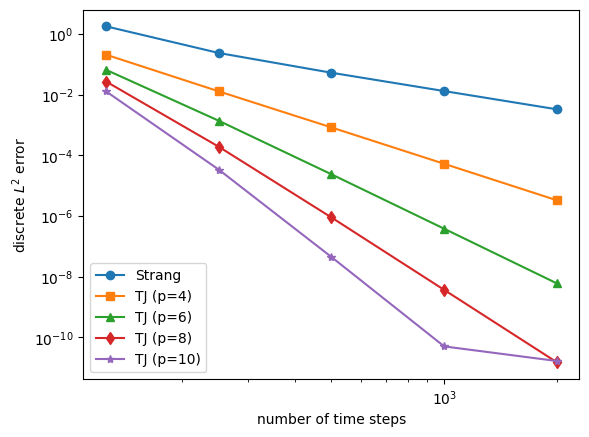

observed orders:
Strang     [2.92 2.17 2.01 2.  ]
TJ (p=4)   [4.02 3.96 3.99 4.  ]
TJ (p=6)   [5.58 5.87 5.97 5.99]
TJ (p=8)   [7.15 7.75 7.94 7.94]
TJ (p=10)  [8.58 9.58 9.8  1.6 ]


In [2]:
tspan = [0, 25]
nsteps_list = np.array([125, 250, 500, 1000, 2000])

sol = reference_solution(system, x0, tspan)
l2_error = np.zeros((len(orders), len(nsteps_list)))
for j, p in enumerate(orders):
    for i, nsteps in enumerate(nsteps_list):
        t, v, w = ess_strang_dg(system, x0, tspan, nsteps, order=p)
        l2_error[j, i] = discrete_l2_error(sol, t, v)

for j in range(len(orders)):
    plt.loglog(nsteps_list, l2_error[j], marker=markers[j], label=labels[j])
plt.xlabel("number of time steps")
plt.ylabel(r"discrete $L^2$ error")
plt.legend()
plt.show()

print("observed orders:")
for j, p in enumerate(orders):
    print(f"{labels[j]:10s}", np.round(np.log2(l2_error[j, :-1] / l2_error[j, 1:]), 2))

## Figure 1b: energy behavior on $[0, 100]$ with $h = 0.5$

max |H(v_n) - H(x_0)| = 1.509903313490213e-14
max |H(w_n) - H(x_0)| = 2.864375403532904e-14


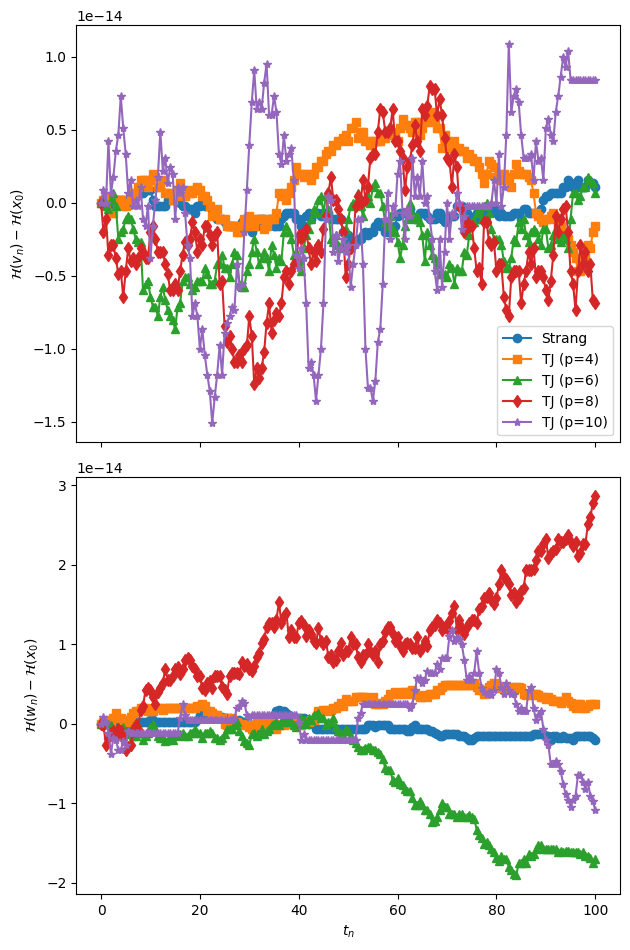

In [3]:
tspan = [0, 100]
nsteps = 200
H0 = system.H(x0)

energy_v = np.zeros((len(orders), nsteps + 1))
energy_w = np.zeros((len(orders), nsteps + 1))
for j, p in enumerate(orders):
    t, v, w = ess_strang_dg(system, x0, tspan, nsteps, order=p)
    energy_v[j] = [hamiltonian_or_nan(system, v[:, n]) - H0 for n in range(nsteps + 1)]
    energy_w[j] = [hamiltonian_or_nan(system, w[:, n]) - H0 for n in range(nsteps + 1)]

assert np.all(np.isfinite(energy_v)) and np.all(np.isfinite(energy_w)), "iterates left the state space"
print("max |H(v_n) - H(x_0)| =", np.max(np.abs(energy_v)))
print("max |H(w_n) - H(x_0)| =", np.max(np.abs(energy_w)))

fig, (ax_v, ax_w) = plt.subplots(2, 1, figsize=(6.4, 9.6), sharex=True)
for j in range(len(orders)):
    ax_v.plot(t, energy_v[j], marker=markers[j], label=labels[j])
    ax_w.plot(t, energy_w[j], marker=markers[j], label=labels[j])
ax_v.set_ylabel(r"$\mathcal{H}(v_n) - \mathcal{H}(x_0)$")
ax_w.set_ylabel(r"$\mathcal{H}(w_n) - \mathcal{H}(x_0)$")
ax_w.set_xlabel(r"$t_n$")
ax_v.legend()
fig.tight_layout()
plt.show()

## Figures 2a and 2b: one-sided vs. symmetric consistent approximations on $[0, 25]$ with $h = 0.01$

The integration is not stopped when $w$ leaves the state space.

one-sided: w leaves the state space at t = 20.46
one-sided: max |H(v_n) - H(x_0)| = 1.15e-14
one-sided: min_n min_i (v_n)_i  = 0.4064
t = 10.00: error one-sided = 7.36e-04, error symmetric = 3.07e-05, w = [1.3194777 1.1369305]
t = 15.00: error one-sided = 1.07e-02, error symmetric = 2.83e-04, w = [0.9487762  1.12623469]
t = 20.00: error one-sided = 3.39e-01, error symmetric = 5.99e-04, w = [0.39884472 0.65137752]
t = 20.46: error one-sided = 5.81e-01, error symmetric = 9.74e-04, w = [-0.00378648  0.67170175]
t = 25.00: error one-sided = 3.22e-01, error symmetric = 1.09e-03, w = [-3.85220134  0.44522577]


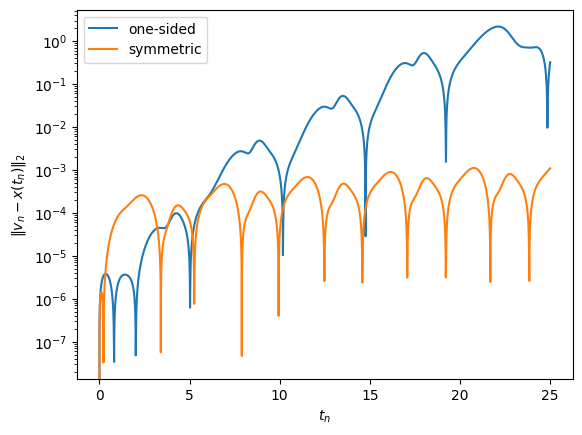

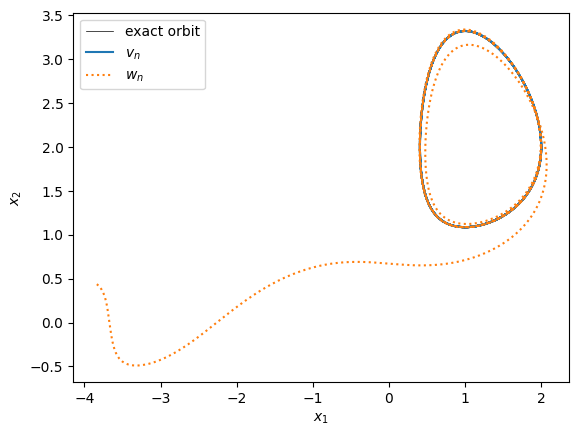

In [4]:
tspan = [0, 25]
nsteps = 2500
H0 = system.H(x0)

sol = reference_solution(system, x0, tspan)
t, v_one_sided, w_one_sided = ess_strang_dg_one_sided(system, x0, tspan, nsteps)
t, v_symmetric, _ = ess_strang_dg(system, x0, tspan, nsteps, order=2)
x_ref = sol.sol(t)

error_one_sided = np.linalg.norm(v_one_sided - x_ref, axis=0)
error_symmetric = np.linalg.norm(v_symmetric - x_ref, axis=0)
energy_error = np.abs([system.H(v_one_sided[:, n]) - H0 for n in range(nsteps + 1)])
leave = np.argmax(np.any(w_one_sided <= 0, axis=0))

print(f"one-sided: w leaves the state space at t = {t[leave]:.2f}")
print(f"one-sided: max |H(v_n) - H(x_0)| = {np.max(energy_error):.2e}")
print(f"one-sided: min_n min_i (v_n)_i  = {v_one_sided.min():.4f}")
for t_eval in [10, 15, 20, t[leave], 25]:
    n = int(round(t_eval / (t[1] - t[0])))
    print(f"t = {t_eval:5.2f}: error one-sided = {error_one_sided[n]:.2e}, "
          f"error symmetric = {error_symmetric[n]:.2e}, w = {w_one_sided[:, n]}")

plt.figure()
plt.semilogy(t, error_one_sided, label="one-sided")
plt.semilogy(t, error_symmetric, label="symmetric")
plt.xlabel(r"$t_n$")
plt.ylabel(r"$\Vert v_n - x(t_n) \Vert_2$")
plt.legend()
plt.show()

t_fine = np.linspace(tspan[0], tspan[1], 2000)
plt.figure()
plt.plot(*sol.sol(t_fine), "k", lw=0.5, label="exact orbit")
plt.plot(v_one_sided[0], v_one_sided[1], label=r"$v_n$")
plt.plot(w_one_sided[0], w_one_sided[1], ":", label=r"$w_n$")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.legend()
plt.show()